## Homework 2

> [!NOTE]
> This homework uses the pinned 2026 car fuel-efficiency release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

### Dataset

For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`


### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.


### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.


In [1]:
import pandas as pd
import numpy as np

# Prepare the dataset

In [2]:
# Read data from CSV file
data = pd.read_csv('car_fuel_efficiency_2026.csv')

In [3]:
data.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
columns_to_keep = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [5]:
data_filtered = data[columns_to_keep]

In [6]:
data_filtered.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: >

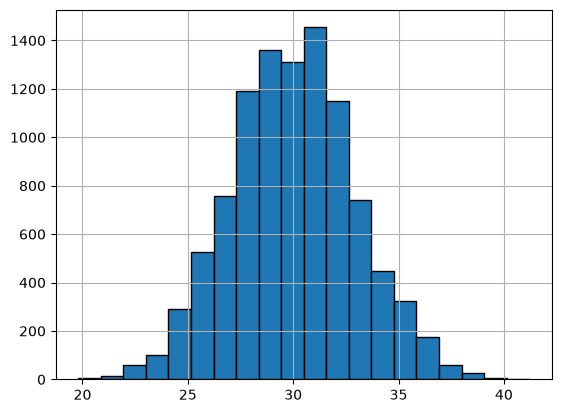

In [7]:
# Check the distribution of the variable fuel_efficiency_mpg
data_filtered["fuel_efficiency_mpg"].hist(bins=20, edgecolor='black')

In [9]:
# Question 1: Column with missing values
data_filtered.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [10]:
# Question 2: Median for horsepower
median_horsepower = data_filtered['horsepower'].median()
median_horsepower

np.float64(254.0)

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good

In [35]:
# Prepare and split the dataset
n = len(data_filtered)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = data_filtered.iloc[idx[:n_train]]
df_val = data_filtered .iloc[idx[n_train:n_train + n_val]]
df_test = data_filtered.iloc[idx[n_train + n_val:]]

In [36]:
target_variable = 'fuel_efficiency_mpg'
column_with_missing_values = 'horsepower'

In [37]:
df_train_zero_fill = df_train.copy()
df_train_mean_fill = df_train.copy()

# Creaet both dataset with missing values filled with zero and mean
df_train_zero_fill[column_with_missing_values] = df_train[column_with_missing_values].fillna(0)
df_train_mean_fill[column_with_missing_values] = df_train[column_with_missing_values].fillna(df_train_mean_fill[column_with_missing_values].mean())

In [38]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [39]:
# Prepare X and Y for training
y_train = df_train[target_variable].to_numpy()

X_zero_fill = df_train_zero_fill.drop(columns=[target_variable]).to_numpy()
X_mean_fill = df_train_mean_fill.drop(columns=[target_variable]).to_numpy()

In [40]:
# Model training with zero fill
w_0_zero_fill, w_zero_fill = train_linear_regression(X_zero_fill, y_train)

# Model training with mean fill
w_0_mean_fill, w_mean_fill = train_linear_regression(X_mean_fill, y_train)

In [41]:
# For train dataset
# Check the prediction with zero fill
y_pred_zero_fill = w_0_zero_fill + X_zero_fill.dot(w_zero_fill)

# Check the prediction with mean fill
y_pred_mean_fill = w_0_mean_fill + X_mean_fill.dot(w_mean_fill)

In [42]:
# For validation dataset
# Prepare X and Y for validation
y_val = df_val[target_variable].to_numpy()

df_val_zero_fill = df_val.copy()
df_val_mean_fill = df_val.copy()

# Creaet both dataset with missing values filled with zero and mean
df_val_zero_fill[column_with_missing_values] = df_val[column_with_missing_values].fillna(0)
# use the mean from the training dataset to fill missing values in the validation dataset
df_val_mean_fill[column_with_missing_values] = df_val[column_with_missing_values].fillna(df_train[column_with_missing_values].mean())


X_val_zero_fill = df_val_zero_fill.drop(columns=[target_variable]).to_numpy()
X_val_mean_fill = df_val_mean_fill.drop(columns=[target_variable]).to_numpy()


# For train dataset
# Check the prediction with zero fill
y_val_pred_zero_fill = w_0_zero_fill + X_val_zero_fill.dot(w_zero_fill)

# Check the prediction with mean fill
y_val_pred_mean_fill = w_0_mean_fill + X_val_mean_fill.dot(w_mean_fill)

In [43]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [45]:
print("RMSE for train dataset with zero fill:", round(rmse(y_val, y_val_pred_zero_fill), 3))
print("RMSE for train dataset with mean fill:", round(rmse(y_val, y_val_pred_mean_fill), 3))

RMSE for train dataset with zero fill: 2.205
RMSE for train dataset with mean fill: 2.202


**Conclusion** :The lower RMSE the better so the fillin na with mean will contribute to a lower RMSE

# Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.




In [46]:
# Prepare and split the dataset
n = len(data_filtered)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = data_filtered.iloc[idx[:n_train]]
df_val = data_filtered .iloc[idx[n_train:n_train + n_val]]
df_test = data_filtered.iloc[idx[n_train + n_val:]]

In [47]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [48]:
# Prepare the training dataset
y_train = df_train[target_variable].to_numpy()

# Fill missing values with zero for training dataset
df_train[column_with_missing_values] = df_train[column_with_missing_values].fillna(0)
X_train = df_train.drop(columns=[target_variable]).to_numpy()


In [49]:
# Save dictionary of results

w_0_dict = {}
w_dict = {}

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    w_0_dict[r] = w_0
    w_dict[r] = w

In [50]:
# Prepare the validation dataset
y_val = df_val[target_variable].to_numpy()

# Creaet both dataset with missing values filled with zero and mean
df_val[column_with_missing_values] = df_val[column_with_missing_values].fillna(0)

X_val = df_val.drop(columns=[target_variable]).to_numpy()

# Save dictionary of results for RMSE
rmse_dict = {}
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0 = w_0_dict[r]
    w = w_dict[r]
    y_val_pred = w_0 + X_val.dot(w)
    rmse_dict[r] = round(rmse(y_val, y_val_pred), 4)

#print the RMSE for each regularization parameter
rmse_dict

{0: np.float64(2.2053),
 0.01: np.float64(2.2058),
 0.1: np.float64(2.2241),
 1: np.float64(2.3492),
 5: np.float64(2.4094),
 10: np.float64(2.4195),
 100: np.float64(2.4292)}

### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

In [91]:
def prepare_train_val_test(df, seed= 42, column_with_missing_values=None, fill_value=0, validation_size=0.2, test_size=0.2):
        # Copy the dataframe to avoid modifying the original
    df_copy = df.copy()

    if column_with_missing_values:
        df_copy[column_with_missing_values] = df_copy[column_with_missing_values].fillna(fill_value)

    # Split the dataset into train, validation, and test sets
    # Prepare and split the dataset
    n = len(df_copy)
    n_val = int(n * validation_size)
    n_test = int(n * test_size)
    n_train = n - n_val - n_test

    # Set the seed for reproducibility
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df_copy.iloc[idx[:n_train]]
    df_val = df_copy .iloc[idx[n_train:n_train + n_val]]
    df_test = df_copy.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test

In [92]:
def prepare_X_y(df, target_variable):
    y = df[target_variable].to_numpy()
    X = df.drop(columns=[target_variable]).to_numpy()
    return X, y

In [98]:
mse_dict = {}

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    # TRAIN, VAL, TEST
    df_train, df_val, df_test = prepare_train_val_test(data_filtered, seed=seed, column_with_missing_values=column_with_missing_values, fill_value=0)
    X_train, y_train = prepare_X_y(df_train, target_variable)
    X_val, y_val = prepare_X_y(df_val, target_variable)

    # Train the model without regularization
    w_0, w = train_linear_regression(X_train, y_train)
    y_val_pred = w_0 + X_val.dot(w)

    # Calculate RMSE and standard deviation of predictions
    rmse_dict[seed] = rmse(y_val, y_val_pred)

# print("RMSE for each seed:", rmse_dict)
print("Std of RMSE across seeds:", round(np.std(list(rmse_dict.values())), 3))


Std of RMSE across seeds: 0.028


# Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

In [100]:
seed = 9

# TRAIN, VAL, TEST
df_train, df_val, df_test = prepare_train_val_test(data_filtered, seed=seed, column_with_missing_values=column_with_missing_values, fill_value=0)

# Combine train and validation datasets for final training
df_train = pd.concat([df_train, df_val], ignore_index=True)
X_train, y_train = prepare_X_y(df_train, target_variable)
X_test, y_test = prepare_X_y(df_test, target_variable)

# Train the model without regularization
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
y_test_pred = w_0 + X_test.dot(w)

# Calculate RMSE and standard deviation of predictions
print(round(rmse(y_test, y_test_pred), 3))

2.236
